# CorrDiff Ensemble Inference Workflow - Modular Version

This notebook demonstrates an advanced ensemble workflow for CorrDiff using modular Python scripts.
All core functionality has been extracted into reusable modules in the `src/` directory.

## Features
- **Modular Design**: Core functionality organized in separate modules
- **Easy Configuration**: Centralized configuration management
- **Ensemble Generation**: Multiple realizations with different seeds
- **Comprehensive Analysis**: Statistical analysis and visualization
- **NetCDF Output**: PhysicsNeMo-compatible output format

## Workflow Overview
1. Load configuration and setup
2. Initialize data source and models
3. Run ensemble inference
4. Save results and analyze statistics
5. Create visualizations

In [1]:
! chmod -R 777 /app/outputs/generation/

In [19]:
! chmod -R 777  /app/notebooks/.Trash-0/

In [21]:
ls /app/notebooks/.Trash-0/files

1_introduction_to_weather_forecasting_with_corrdiff.ipynb*
2_understanding_corrdiff_architecture.ipynb*
3_preparing_weather_data_for_corrdiff.ipynb*
4_training_corrdiff_on_custom_data.ipynb*
5_evaluating_corrdiff_predictions.ipynb*
6_advanced_topics_in_corrdiff.ipynb*
7_deploying_corrdiff_for_weather_forecasting.ipynb*
temp_downloading_hrrr_data.md*
temp_exploring_sample_data.md*


## Setup and Configuration

In [2]:
import os
import sys
import torch

# Add source modules to path
src_path = '/app/host/home/younes.abid/git/earth2studio/notebooks/tutorials/cordiff/src'
sys.path.append(src_path)

# Import modular components
from config import EnsembleConfig
from data_loader import create_data_source
from ensemble_model import create_ensemble_model
from inference import run_ensemble_inference
from output import save_ensemble_netcdf, verify_output
from stats import compute_and_save_stats
from visualization import plot_ensemble_analysis, print_ensemble_summary

print('✅ All modular components imported successfully')

✅ All modular components imported successfully


In [3]:
# Create configuration object
config = EnsembleConfig(variables="Fog_index")
config.NUMBER_OF_STEPS = 20

# Print configuration summary
config.print_config()

✅ Ensemble configuration loaded
📊 Ensemble setup: 4 members, stochastic sampling
🔄 Diffusion steps: 20, solver: euler
💾 Ensemble output: /app/outputs/generation/Fog_index/20260204_082620/ensemble_Fog_index_20260204_082620.nc
📁 Analysis folder: /app/outputs/generation/Fog_index/20260204_082620/analysis


## Data Source and Model Setup

In [4]:
# Create data source
data_source = create_data_source(config)

print('✅ Data source created')
print(f'📊 Available samples: {data_source.total_samples}')
print(f'📐 Input grid shape: {data_source.input_shape}')

🔍 Analyzing data files...
  File 1: 2024-04-30_2024-05-30_21.nc - 504 samples
✅ Total samples across all files: 504
📐 Input grid shape: (432, 432)
📐 Lat range: [19.25, 28.00]
📐 Lon range: [116.00, 125.98]
✅ Loaded normalization stats for 16 input variables
💾 Preloading data into memory...
  Loading file 1/1: 2024-04-30_2024-05-30_21.nc
    ✅ Loaded in 6.27s
✅ Data preloading complete!
✅ Data source created
📊 Available samples: 504
📐 Input grid shape: (432, 432)


In [5]:
# Create ensemble CorrDiff model
ensemble_model = create_ensemble_model(config, data_source)

🔄 Loading regression model: UNet.0.390000.mdlus


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/module.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(


🔄 Loading diffusion model: EDMPrecondSuperResolution.0.590000.mdlus
🎲 Generated 4 ensemble seeds: [1608637542 1273642419 1935803228  787846414]...
✅ Ensemble models loaded successfully
🎯 Model mode: Full CorrDiff
🎲 Sampling: stochastic with 4 ensemble members


## Ensemble Inference

In [6]:
# Run ensemble inference
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = run_ensemble_inference(config, ensemble_model, data_source, device)

print(f'📊 Inference complete: {len(results["predictions"])} time steps with {config.NUM_ENSEMBLES} ensemble members each')

🚀 Starting ensemble inference on cuda
📅 Processing 2 time steps
🎯 Generating 4 ensemble members per time step
🔄 Processing time 1/2: 2024-04-30T00:00:00
🔄 Loading data for 1 times and 16 variables
🎯 Time mapping: 2024-04-30T00:00:00.000000000 -> index 0 (2024-04-30T00:00:00.000000000)
✅ Loaded DataArray with shape: (1, 16, 432, 432)
   📊 Input data shape: torch.Size([1, 16, 36, 40])
🔄 Running stochastic sampling with 20 steps


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


   ✅ Generated ensemble shape: torch.Size([1, 4, 1, 432, 432])
🔄 Processing time 2/2: 2024-05-15T06:00:00
🔄 Loading data for 1 times and 16 variables
🎯 Time mapping: 2024-05-15T06:00:00.000000000 -> index 198 (2024-05-15T06:00:00.000000000)
✅ Loaded DataArray with shape: (1, 16, 432, 432)
   📊 Input data shape: torch.Size([1, 16, 36, 40])
🔄 Running stochastic sampling with 20 steps


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


   ✅ Generated ensemble shape: torch.Size([1, 4, 1, 432, 432])
✅ Ensemble inference complete! Processed 2 time steps
📊 Inference complete: 2 time steps with 4 ensemble members each


## Save Results and Analysis

In [7]:
# Save results in NetCDF format
saved_file = save_ensemble_netcdf(config, results, ensemble_model)

# Verify the saved file
verify_output(saved_file)

💾 Saving ensemble results to: /app/outputs/generation/Fog_index/20260204_082620/ensemble_Fog_index_20260204_082620.nc
   📐 Dimensions: time=2, ensemble=4, lat=432, lon=432
✅ Ensemble results saved to /app/outputs/generation/Fog_index/20260204_082620/ensemble_Fog_index_20260204_082620.nc

📁 Verifying saved file:
   📊 Prediction dataset:
   📐 Dimensions: {'ensemble': 4, 'time': 2, 'y': 432, 'x': 432}
   📋 Variables: ['Fog_index']
   📊 Input dataset:
   📐 Dimensions: {'y_input': 36, 'x_input': 40, 'time': 2}
   📋 Variables: ['y', 'x', 't_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp']


/app/host/home/younes.abid/git/earth2studio/notebooks/tutorials/cordiff/src/output.py:160: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   📐 Dimensions: {dict(ds.dims)}')
/app/host/home/younes.abid/git/earth2studio/notebooks/tutorials/cordiff/src/output.py:165: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   📐 Dimensions: {dict(ds.dims)}')


In [13]:
# Compute and save ensemble statistics
summary_stats, stats_file = compute_and_save_stats(config, saved_file)

📊 Computing fast ensemble summary statistics...
   Fog_index time 0: mean=50.1500, uncertainty=6.6178
   Fog_index time 1: mean=74.5948, uncertainty=7.5841
✅ Summary statistics saved to /app/outputs/generation/Fog_index/20260204_082620/analysis/summary_stats_Fog_index_20260204_082620.json


In [14]:
summary_stats

{'metadata': {'num_ensembles': 4,
  'num_times': 2,
  'variables': ['Fog_index'],
  'computed_at': '2026-02-04T08:30:28.965301'},
 'statistics': {'Fog_index': {'time_0': {'ensemble_mean': {'spatial_mean': 50.1500129699707,
     'spatial_std': 19.996919631958008,
     'spatial_min': -5.036264419555664,
     'spatial_max': 89.67313385009766},
    'ensemble_std': {'spatial_mean': 6.617833137512207,
     'spatial_max': 23.973495483398438,
     'spatial_min': 0.07731126993894577},
    'ensemble_range': {'spatial_mean': 17.016067504882812,
     'spatial_max': 60.54914474487305},
    'raw_ensemble_values': {'min_of_all_members': -30.133968353271484,
     'max_of_all_members': 103.76131439208984,
     'mean_of_all_members': 50.1500129699707}},
   'time_1': {'ensemble_mean': {'spatial_mean': 74.59481811523438,
     'spatial_std': 25.761199951171875,
     'spatial_min': 4.237252235412598,
     'spatial_max': 108.72392272949219},
    'ensemble_std': {'spatial_mean': 7.584133148193359,
     'spati

## Visualization and Analysis

🎨 Creating ensemble members grid for time index 1...
   ✅ Ensemble members grid saved: /app/outputs/generation/Fog_index/20260204_082620/analysis/1/ensemble_members_Fog_index_20260204_082620.png


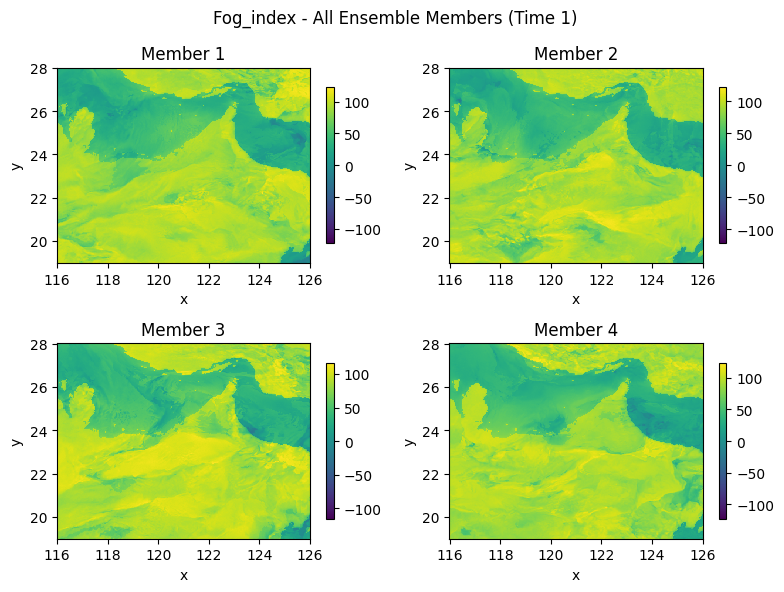

🎨 Creating ensemble statistics plots for time index 1...
   ✅ Ensemble statistics plot saved: /app/outputs/generation/Fog_index/20260204_082620/analysis/1/ensemble_statistics_Fog_index_20260204_082620.png


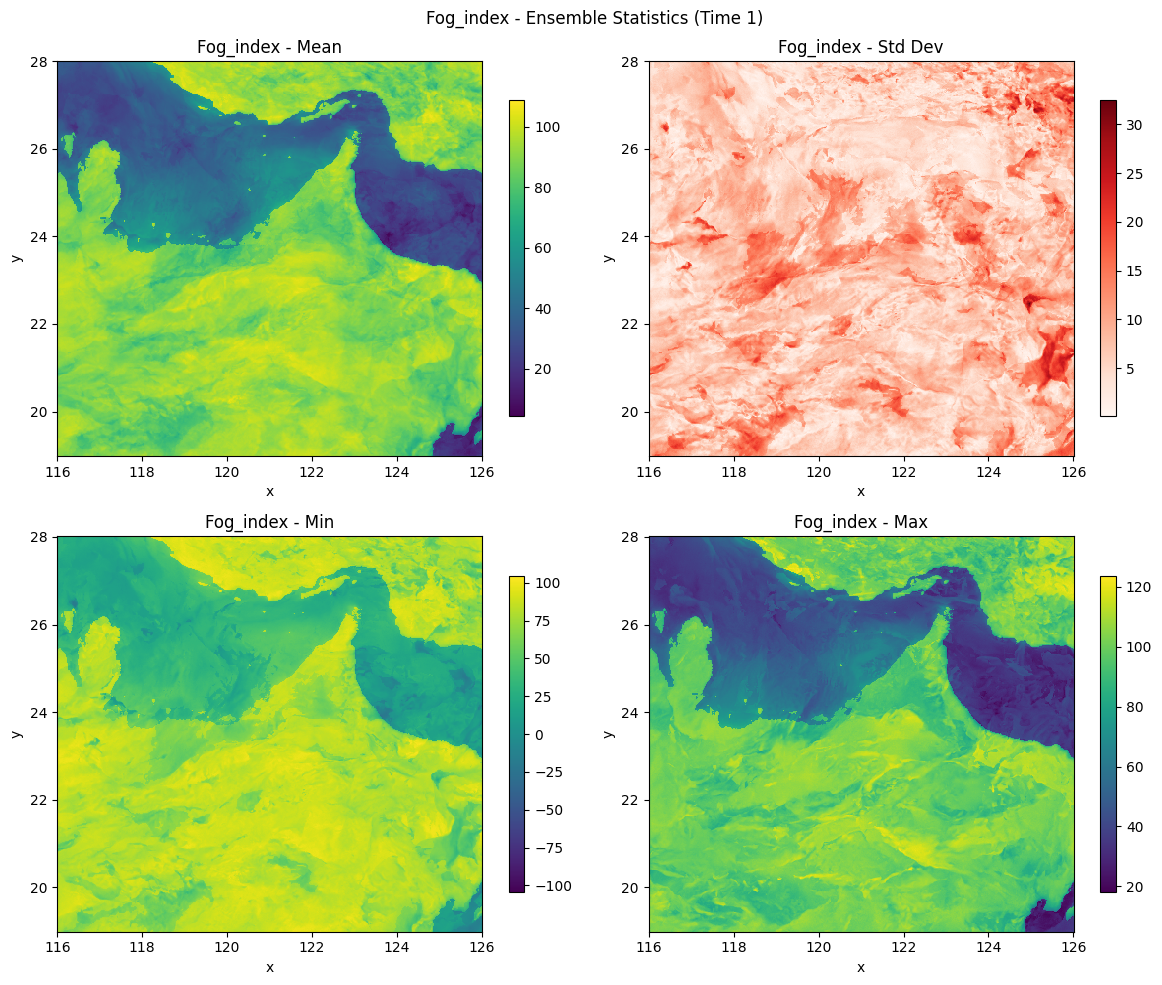

In [9]:
# Create comprehensive ensemble visualizations
plot_ensemble_analysis(config, saved_file, time_idx=1)

In [10]:
# Load and inspect the saved data
import xarray as xr

# Open prediction dataset
pred_ds = xr.open_dataset(saved_file, group='prediction')
pred_ds

<xarray.Dataset> Size: 6MB
Dimensions:    (ensemble: 4, time: 2, y: 432, x: 432)
Coordinates:
  * time       (time) datetime64[ns] 16B 2024-04-30 2024-05-15T06:00:00
  * ensemble   (ensemble) int32 16B 0 1 2 3
  * y          (y) float32 2kB 19.0 19.02 19.04 19.06 ... 27.94 27.96 27.98 28.0
  * x          (x) float32 2kB 116.0 116.0 116.0 116.1 ... 126.0 126.0 126.0
Data variables:
    Fog_index  (ensemble, time, y, x) float32 6MB ...

## Summary and Next Steps

In [15]:
# Print comprehensive summary
print_ensemble_summary(config, results, saved_file, summary_stats)

🎉 ENSEMBLE CORRDIFF INFERENCE COMPLETE!
📊 Configuration Summary:
   • Ensemble members: 4
   • Sampling mode: stochastic
   • Diffusion steps: 20
   • Time steps processed: 2
   • Variables: ['Fog_index']
💾 Output Files:
   • Ensemble data: /app/outputs/generation/Fog_index/20260204_082620/ensemble_Fog_index_20260204_082620.nc
   • Analysis folder: /app/outputs/generation/Fog_index/20260204_082620/analysis
📈 Key Insights:

🔄 To load and analyze the results:
```python
import xarray as xr
pred_ds = xr.open_dataset("/app/outputs/generation/Fog_index/20260204_082620/ensemble_Fog_index_20260204_082620.nc", group="prediction")
ensemble_data = pred_ds["Fog_index"]
```

🚀 Next Steps:
   1. Experiment with different SAMPLING_MODE settings
   2. Adjust NUM_ENSEMBLES for uncertainty requirements
   3. Check analysis folder for saved plots and statistics


## Advanced Configuration Options

You can easily modify the ensemble configuration by creating a new config object:

```python
# Example: Different sampling configuration
custom_config = EnsembleConfig(variables="Fog_index")
custom_config.SAMPLING_MODE = 'deterministic'
custom_config.NUM_ENSEMBLES = 16
custom_config.NUMBER_OF_STEPS = 50
custom_config.INFERENCE_TIMES = ['2024-05-01T00:00:00', '2024-05-02T00:00:00']

# Run with custom configuration
# data_source = create_data_source(custom_config)
# ensemble_model = create_ensemble_model(custom_config, data_source)
# results = run_ensemble_inference(custom_config, ensemble_model, data_source)
```

## Module Structure

The workflow is organized into these modules in `src/`:

- **`config.py`**: Configuration management and parameter settings
- **`data_loader.py`**: Custom data source for PhysicsNeMo format
- **`ensemble_model.py`**: Ensemble CorrDiff model implementation
- **`inference.py`**: Inference workflow and execution
- **`output.py`**: NetCDF output and statistical analysis
- **`visualization.py`**: Plotting and visualization functions

This modular design makes it easy to:
- Modify individual components without affecting others
- Reuse functions across different notebooks
- Test and debug specific functionality
- Extend the workflow with new features

## Troubleshooting

If you encounter visualization issues with cartopy (geographic projections), the visualization module automatically uses simple matplotlib plots instead. This provides the same ensemble analysis without geographic context but is more reliable across different environments.

The modular design allows you to easily swap out components or add new functionality as needed.